# Baseline Cross-sectional Comparison of HC1|CONV|NONC|ERA

# Olink-specific Demographics QC

In [1]:
quiet_library <- function(...){
    suppressPackageStartupMessages(library(...))
}

In [2]:
quiet_library(hise)
quiet_library(dplyr)
quiet_library(stats)
quiet_library(dunn.test)
quiet_library(ggplot2)
quiet_library(RColorBrewer)

## Read in baseline ARI olink data

In [3]:
# from IDE for ALTRA Olink Data for Aim 1: CON | ARI (No Subject Metadata) 2024-12-18

a1_uuid <- 'cc6d77a7-7299-42a8-a0dc-b7edaf056c67' # vadof-pofus-pigip/2024-12-18_Olink_altraHCvARI_noMeta.csv

In [4]:
a1_file <- cacheFiles(list(a1_uuid))

a1 <- read.csv(a1_file, 
               header = T, 
               stringsAsFactors = F)

nrow(a1)

[1] "downloading fileID cc6d77a7-7299-42a8-a0dc-b7edaf056c67"


[1] 108283

## Read in baseline ERA olink data

In [5]:
# from IDE for ALTRA Olink Data for Aim 2 (CON | ERA) 2024-10-22

a2_uuid <- '78d58a68-f030-4ef5-b60a-4aedb2a5ad85' # tafug-kasir-kasap/2024-10-22_Olink_altraHCvERA.csv

In [6]:
a2_file <- cacheFiles(list(a2_uuid))

a2 <- read.csv(a2_file, 
               header = T, 
               stringsAsFactors = F)

nrow(a2)

[1] "downloading fileID 78d58a68-f030-4ef5-b60a-4aedb2a5ad85"


[1] 85294

In [7]:
terms <- c('sample', 'subject', 'cohort', 'age', 'time', 'bmi', 'BMI', 'days', 'Status', 'aim')

keep_a2 <- a2 %>%
    select(SampleID,
           sample.sampleKitGuid,
           !contains(terms))

nrow(keep_a2)

[1] 85294

## Read in metadata

In [8]:
meta_uuid <- '32b8bb9c-4834-4e5c-9b3a-7939b3b7f057'

In [9]:
meta_file <- cacheFiles(list(meta_uuid))

meta <- read.csv(meta_file, 
                 header = T, stringsAsFactors = F)

nrow(meta)

[1] "downloading fileID 32b8bb9c-4834-4e5c-9b3a-7939b3b7f057"


[1] 157

In [10]:
conv <- c('CU1003', 'CU1007', 'CU1009', 'CU1010', 'CU1015', 'CU1021', 'CU1029', 
          'CU1033', 'CU1037', 'CU1039', 'CU1044', 'CU1050', 'CU1052', 'CU1053', 
          'SD1003', 'SD1007')

outSubj <- c('CU1002')

outCols <- c('Status_Long')

In [11]:
meta2 <- meta %>%
    select(-any_of(outCols)) %>%
    filter(!subject.subjectGuid %in% outSubj, 
           Status_Xsec %in% c('ALTRA_healthy', 'at_risk') | 
           Status_Xsec == 'early_RA' & !subject.subjectGuid %in% conv) %>%
    mutate(Status = ifelse(Status_Xsec == 'ALTRA_healthy' | Status_Xsec == 'early_RA', 
                           Status_Xsec, 
                           ifelse(Status_Xsec == 'at_risk' & subject.subjectGuid %in% conv, 
                                  'converter', 
                                  'non_converter')))

In [12]:
table(meta2$Status, meta2$Status_Xsec)

               
                ALTRA_healthy at_risk early_RA
  ALTRA_healthy            38       0        0
  converter                 0      14        0
  early_RA                  0       0       11
  non_converter             0      30        0

## Merge olink data and metadata

In [13]:
risk <- a1 %>%
    inner_join(meta2, by = 'sample.sampleKitGuid')

nrow(risk)

[1] 106961

In [14]:
era <- keep_a2 %>%
    inner_join(meta2, by = 'sample.sampleKitGuid') %>%
    filter(Status == 'early_RA')

nrow(era)

[1] 14727

In [15]:
all <- risk %>%
    bind_rows(era)

nrow(all)

New names:
• `record_id...112` -> `record_id...146`
• `record_id...120` -> `record_id...154`
• `record_id...114` -> `record_id...158`
• `record_id...123` -> `record_id...159`
New names:
• `record_id...112` -> `record_id...146`
• `record_id...120` -> `record_id...154`
• `record_id...114` -> `record_id...158`
• `record_id...123` -> `record_id...159`


[1] 121688

## QC Demographics

In [16]:
QC <- all %>%
    distinct(sample.sampleKitGuid, .keep_all = T)

table(QC$Status)


ALTRA_healthy     converter      early_RA non_converter 
           37            14            11            30 

#### Age

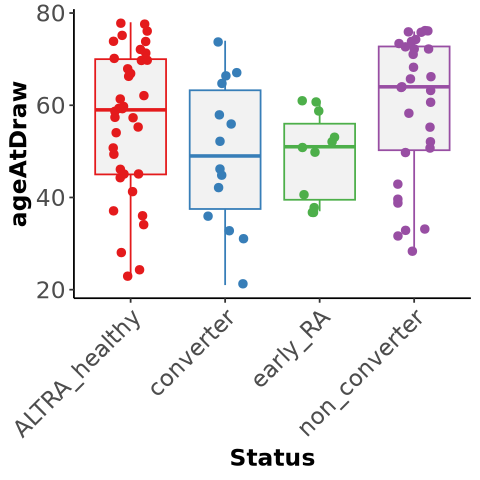

In [17]:
options(repr.plot.width = 4, repr.plot.height = 4) # default 7x7

ggplot(QC, aes(x=Status, 
               y=ageAtDraw,
               colour=Status)) + 
    geom_boxplot(fill = 'gray95', 
                 outlier.shape = NA) + 
    geom_jitter(position = position_jitter(0.2), 
                cex = 2) + 
    scale_colour_brewer(palette = 'Set1') + 
    theme_classic() + 
    theme (plot.title = element_text(size=14, face='bold', hjust=0.5), 
           legend.position = 'none',
           #legend.text = element_text(size = 14),
           #legend.title = element_text(size=14),
           axis.text.y = element_text(size = 14),
           axis.text.x = element_text(size = 14, angle = 45, hjust = 1, vjust = 1), 
           axis.title.y = element_text(size = 14, face='bold'), 
           axis.title.x = element_text(size = 14, face = 'bold'))

In [18]:
kruskal.test(ageAtDraw ~ Status, 
             data = QC)


	Kruskal-Wallis rank sum test

data:  ageAtDraw by Status
Kruskal-Wallis chi-squared = 7.1143, df = 3, p-value = 0.06834


#### Sex

In [19]:
a <- table(QC$subject.biologicalSex, QC$Status)
a

        
         ALTRA_healthy converter early_RA non_converter
  Female            33        12       10            23
  Male               4         2        1             7

In [20]:
chisq.test(a, simulate.p.value = T)


	Pearson's Chi-squared test with simulated p-value (based on 2000
	replicates)

data:  a
X-squared = 2.4179, df = NA, p-value = 0.5387


#### Ethnicity and Race

In [21]:
a <- table(QC$subject.ethnicity, QC$Status)
a

                           
                            ALTRA_healthy converter early_RA non_converter
  Hispanic or Latino origin             9         1        3             1
  Non-Hispanic origin                  28        13        8            29

In [22]:
chisq.test(a, simulate.p.value = T)


	Pearson's Chi-squared test with simulated p-value (based on 2000
	replicates)

data:  a
X-squared = 7.6091, df = NA, p-value = 0.04898


In [23]:
a <- table(QC$subject.race, QC$Status)
a

                  
                   ALTRA_healthy converter early_RA non_converter
  African American             0         2        2             2
  Asian                        3         0        1             1
  Caucasian                   31        10        7            26
  Other                        3         2        1             1

In [24]:
chisq.test(a, simulate.p.value = T)


	Pearson's Chi-squared test with simulated p-value (based on 2000
	replicates)

data:  a
X-squared = 10.071, df = NA, p-value = 0.3423


#### BMI

Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”


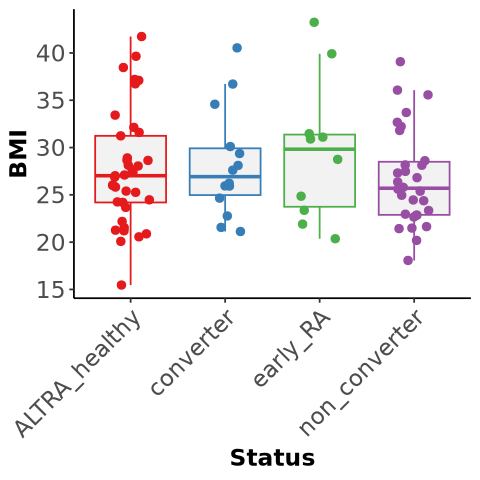

In [25]:
options(repr.plot.width = 4, repr.plot.height = 4) # default 7x7

ggplot(QC, aes(x=Status, 
               y=BMI,
               colour=Status)) + 
    geom_boxplot(fill = 'gray95', 
                 outlier.shape = NA) + 
    geom_jitter(position = position_jitter(0.2), 
                cex = 2) + 
    scale_colour_brewer(palette = 'Set1') + 
    theme_classic() + 
    theme (plot.title = element_text(size=14, face='bold', hjust=0.5), 
           legend.position = 'none',
           #legend.text = element_text(size = 14),
           #legend.title = element_text(size=14),
           axis.text.y = element_text(size = 14),
           axis.text.x = element_text(size = 14, angle = 45, hjust = 1, vjust = 1), 
           axis.title.y = element_text(size = 14, face='bold'), 
           axis.title.x = element_text(size = 14, face = 'bold'))

In [26]:
kruskal.test(BMI ~ Status, 
             data = QC)


	Kruskal-Wallis rank sum test

data:  BMI by Status
Kruskal-Wallis chi-squared = 1.4559, df = 3, p-value = 0.6925


#### CCP3

Warning message:
“Removed 2 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”


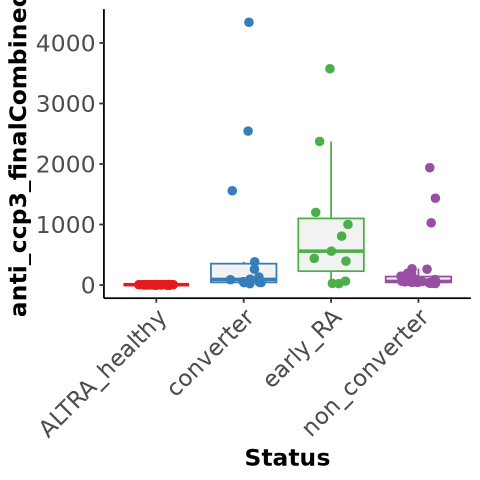

In [27]:
options(repr.plot.width = 4, repr.plot.height = 4) # default 7x7

ggplot(QC, aes(x=Status, 
               y=anti_ccp3_finalCombined,
               colour=Status)) + 
    geom_boxplot(fill = 'gray95', 
                 outlier.shape = NA) + 
    geom_jitter(position = position_jitter(0.2), 
                cex = 2) + 
    scale_colour_brewer(palette = 'Set1') + 
    theme_classic() + 
    theme (plot.title = element_text(size=14, face='bold', hjust=0.5), 
           legend.position = 'none',
           #legend.text = element_text(size = 14),
           #legend.title = element_text(size=14),
           axis.text.y = element_text(size = 14),
           axis.text.x = element_text(size = 14, angle = 45, hjust = 1, vjust = 1), 
           axis.title.y = element_text(size = 14, face='bold'), 
           axis.title.x = element_text(size = 14, face = 'bold'))

In [28]:
kruskal.test(anti_ccp3_finalCombined ~ Status, 
             data = QC)


	Kruskal-Wallis rank sum test

data:  anti_ccp3_finalCombined by Status
Kruskal-Wallis chi-squared = 66.565, df = 3, p-value = 2.32e-14


In [29]:
dunn.test(QC$anti_ccp3_finalCombined, QC$Status, 
          method = 'Bonferroni', 
          alpha = 0.05, 
          altp = TRUE)

  Kruskal-Wallis rank sum test

data: x and group
Kruskal-Wallis chi-squared = 66.5654, df = 3, p-value = 0


                           Comparison of x by group                            
                                 (Bonferroni)                                  
Col Mean-|
Row Mean |   ALTRA_he   converte   early_RA
---------+---------------------------------
converte |  -5.582655
         |    0.0000*
         |
early_RA |  -6.022481  -0.785128
         |    0.0000*     1.0000
         |
non_conv |  -6.436002   0.506907   1.362934
         |    0.0000*     1.0000     1.0000

alpha = 0.05
Reject Ho if p <= alpha


#### RF-IgM

In [33]:
# remove 999

rfm <- QC %>%
    filter(rfigm_result < 999)

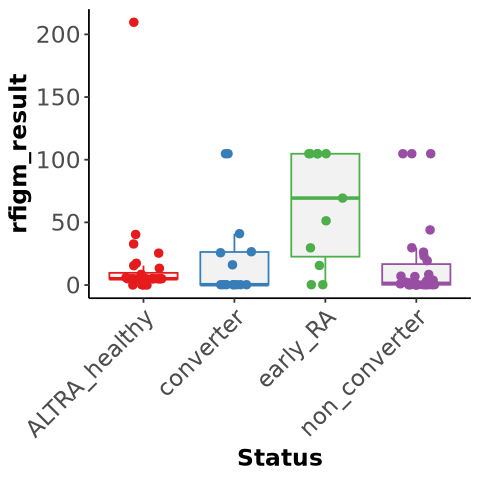

In [34]:
options(repr.plot.width = 4, repr.plot.height = 4) # default 7x7

ggplot(rfm, aes(x=Status, 
                y=rfigm_result,
                colour=Status)) + 
    geom_boxplot(fill = 'gray95', 
                 outlier.shape = NA) + 
    geom_jitter(position = position_jitter(0.2), 
                cex = 2) + 
    scale_colour_brewer(palette = 'Set1') + 
    theme_classic() + 
    theme (plot.title = element_text(size=14, face='bold', hjust=0.5), 
           legend.position = 'none',
           #legend.text = element_text(size = 14),
           #legend.title = element_text(size=14),
           axis.text.y = element_text(size = 14),
           axis.text.x = element_text(size = 14, angle = 45, hjust = 1, vjust = 1), 
           axis.title.y = element_text(size = 14, face='bold'), 
           axis.title.x = element_text(size = 14, face = 'bold'))

In [35]:
kruskal.test(rfigm_result ~ Status, 
             data = rfm)


	Kruskal-Wallis rank sum test

data:  rfigm_result by Status
Kruskal-Wallis chi-squared = 10.179, df = 3, p-value = 0.0171


In [36]:
dunn.test(rfm$rfigm_result, rfm$Status, 
          method = 'Bonferroni', 
          alpha = 0.05, 
          altp = TRUE)

  Kruskal-Wallis rank sum test

data: x and group
Kruskal-Wallis chi-squared = 10.1791, df = 3, p-value = 0.02


                           Comparison of x by group                            
                                 (Bonferroni)                                  
Col Mean-|
Row Mean |   ALTRA_he   converte   early_RA
---------+---------------------------------
converte |   0.529595
         |     1.0000
         |
early_RA |  -2.350293  -2.505969
         |     0.1126     0.0733
         |
non_conv |   1.001991   0.277880   3.119677
         |     1.0000     1.0000    0.0109*

alpha = 0.05
Reject Ho if p <= alpha


#### RF-IgA

In [37]:
# remove 999

rfa <- QC %>%
    filter(rfiga_result < 999)

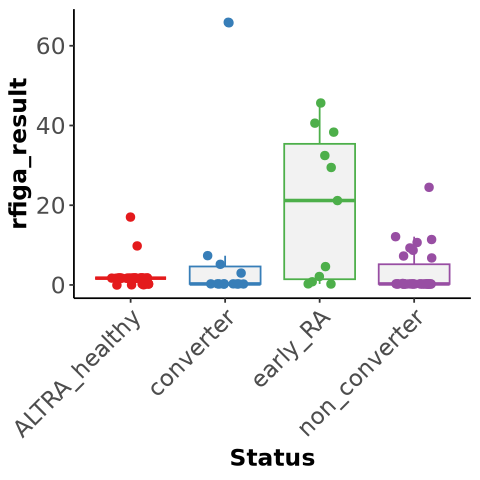

In [38]:
options(repr.plot.width = 4, repr.plot.height = 4) # default 7x7

ggplot(rfa, aes(x=Status, 
               y=rfiga_result,
               colour=Status)) + 
    geom_boxplot(fill = 'gray95', 
                 outlier.shape = NA) + 
    geom_jitter(position = position_jitter(0.2), 
                cex = 2) + 
    scale_colour_brewer(palette = 'Set1') + 
    theme_classic() + 
    theme (plot.title = element_text(size=14, face='bold', hjust=0.5), 
           legend.position = 'none',
           #legend.text = element_text(size = 14),
           #legend.title = element_text(size=14),
           axis.text.y = element_text(size = 14),
           axis.text.x = element_text(size = 14, angle = 45, hjust = 1, vjust = 1), 
           axis.title.y = element_text(size = 14, face='bold'), 
           axis.title.x = element_text(size = 14, face = 'bold'))

In [39]:
kruskal.test(rfiga_result ~ Status, 
             data = rfa)


	Kruskal-Wallis rank sum test

data:  rfiga_result by Status
Kruskal-Wallis chi-squared = 11.908, df = 3, p-value = 0.007705


In [40]:
dunn.test(rfa$rfiga_result, rfa$Status, 
          method = 'Bonferroni', 
          alpha = 0.05, 
          altp = TRUE)

  Kruskal-Wallis rank sum test

data: x and group
Kruskal-Wallis chi-squared = 11.908, df = 3, p-value = 0.01


                           Comparison of x by group                            
                                 (Bonferroni)                                  
Col Mean-|
Row Mean |   ALTRA_he   converte   early_RA
---------+---------------------------------
converte |   0.697534
         |     1.0000
         |
early_RA |  -2.220406  -2.461344
         |     0.1583     0.0831
         |
non_conv |   1.674942   0.611893   3.375379
         |     0.5637     1.0000    0.0044*

alpha = 0.05
Reject Ho if p <= alpha


In [41]:
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS/LAPACK: /home/workspace/environment/olink/lib/libopenblasp-r0.3.27.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=C.UTF-8    LC_NUMERIC=C        LC_TIME=C          
 [4] LC_COLLATE=C        LC_MONETARY=C       LC_MESSAGES=C      
 [7] LC_PAPER=C          LC_NAME=C           LC_ADDRESS=C       
[10] LC_TELEPHONE=C      LC_MEASUREMENT=C    LC_IDENTIFICATION=C

time zone: America/Los_Angeles
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] RColorBrewer_1.1-3 ggplot2_3.5.1      dunn.test_1.3.6    dplyr_1.1.4       
[5] hise_2.16.0       

loaded via a namespace (and not attached):
 [1] gtable_0.3.5      jsonlite_1.8.8    compiler_4.3.3    crayon_1.5.3     
 [5] tidyselect_1.2.1  IRdisplay_1.1     bitops_1.0-8      assertthat_0.2.1 
 [9] scales_1